In [1]:
""" This demo takes OLMoE as an example. """
import sys
sys.path.append(".")
import os
import torch
from tools import *
from dataset.c4_dataset import *
from dataset.ioi_dataset import *
from transformers import AutoTokenizer
from huggingface_hub import list_repo_refs
out = list_repo_refs("allenai/OLMoE-1B-7B-0924")
branches = [b.name for b in out.branches]
print(branches)
###-------- Basic settings --------####
# output_dir = "./results/"
output_dir = "./results/step10000-tokens41B"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
torch.set_default_device("cuda:0") # or "cpu"
torch.set_grad_enabled(False)
####-------- Model settings --------####
model_id = "allenai/OLMoE-1B-7B-0924"
n_layers = 16
n_dim = 2048
n_heads = 16
n_experts = 64
top_k = 8
####-------- Model loading --------####
from customized_models.modeling_olmoe_customized import OlmoeForCausalLM
# model = OlmoeForCausalLM.from_pretrained(model_id, attn_implementation="eager")
# model = OlmoeForCausalLM.from_pretrained("allenai/OLMoE-1B-7B-0924", revision='step10000-tokens41B', attn_implementation="eager")
# model = OlmoeForCausalLM.from_pretrained("allenai/OLMoE-1B-7B-0924", revision='step100000-tokens419B', attn_implementation="eager")
# model = OlmoeForCausalLM.from_pretrained("allenai/OLMoE-1B-7B-0924", revision='step200000-tokens838B', attn_implementation="eager")
# model = OlmoeForCausalLM.from_pretrained("allenai/OLMoE-1B-7B-0924", revision='step500000-tokens2097B', attn_implementation="eager")
# model = OlmoeForCausalLM.from_pretrained("allenai/OLMoE-1B-7B-0924", revision='step1000000-tokens4194B', attn_implementation="eager")
tokenizer = AutoTokenizer.from_pretrained(model_id)
my_c4_dataset = c4_dataset_helper(dataset_len=500, seed=None, min_words=32) # use a small number of samples to test if the program runs normally

/home/wengang/.conda/envs/paper_routing_decision/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


['main', 'step995000-tokens4173B', 'step990000-tokens4152B', 'step985000-tokens4131B', 'step980000-tokens4110B', 'step975000-tokens4089B', 'step970000-tokens4068B', 'step965000-tokens4047B', 'step960000-tokens4026B', 'step955000-tokens4005B', 'step950000-tokens3984B', 'step95000-tokens398B', 'step945000-tokens3963B', 'step940000-tokens3942B', 'step935000-tokens3921B', 'step930000-tokens3900B', 'step925000-tokens3879B', 'step920000-tokens3858B', 'step915000-tokens3837B', 'step910000-tokens3816B', 'step905000-tokens3795B', 'step900000-tokens3774B', 'step90000-tokens377B', 'step895000-tokens3753B', 'step890000-tokens3732B', 'step885000-tokens3711B', 'step880000-tokens3690B', 'step875000-tokens3670B', 'step870000-tokens3649B', 'step865000-tokens3628B', 'step860000-tokens3607B', 'step855000-tokens3586B', 'step850000-tokens3565B', 'step85000-tokens356B', 'step845000-tokens3544B', 'step840000-tokens3523B', 'step835000-tokens3502B', 'step830000-tokens3481B', 'step825000-tokens3460B', 'step8200

In [2]:
# test_checkpoints = ['step10000-tokens41B', 'step50000-tokens209B','step100000-tokens419B', 'step125000-tokens524B', 'step150000-tokens629B', 'step200000-tokens838B', 'step500000-tokens2097B', 'step1000000-tokens4194B', 'main']
# test_checkpoints = ['step100000-tokens419B', 'step125000-tokens524B', 'step130000-tokens545B', 'step135000-tokens566B', 'step140000-tokens587B']
# test_checkpoints = ['step5000-tokens20B', 'step50000-tokens209B', 'step100000-tokens419B', 'step125000-tokens524B', 'step130000-tokens545B', 'step135000-tokens566B', 'step140000-tokens587B', 'main']
# test_checkpoints = ['step5000-tokens20B', 'step50000-tokens209B', 'step125000-tokens524B', 'step130000-tokens545B', 'step135000-tokens566B', 'main']
# test_checkpoints = ['step100000-tokens419B', 'step200000-tokens838B', 'step500000-tokens2097B', 'step750000-tokens3145B', 'step1000000-tokens4194B', 'main']
# test_checkpoints = ['step10000-tokens41B', 'step125000-tokens524B', 'step130000-tokens545B', 'step135000-tokens566B', 'step250000-tokens1048B', 'step500000-tokens2097B', 'step750000-tokens3145B','step1000000-tokens4194B','main']
test_checkpoints = ['step10000-tokens41B','step130000-tokens545B', 'step135000-tokens566B', 'step400000-tokens1677B', 'step800000-tokens3355B', 'main']
moe_vars = []
for ckpt in test_checkpoints:
    model = OlmoeForCausalLM.from_pretrained(model_id, revision=ckpt, attn_implementation="eager")
    router_weight_ls = [model.model.layers[i].mlp.gate.weight for i in range(n_layers)]
    moe_var = decompose_TAM_tril(my_c4_dataset, model, tokenizer, router_weight_ls, output_dir, n_experts, bsz=50, max_token_per_prompt=32, demo_now=False)
    moe_vars.append(moe_var)

100%|██████████| 10/10 [00:06<00:00,  1.51it/s]


[['A0', 'T', 'A1', 'A2', 'A3'], ['A1', 'A0', 'M0', 'T', 'A2'], ['M1', 'A2', 'M0', 'A0', 'A1'], ['M2', 'M1', 'A3', 'M0', 'A2'], ['M3', 'A4', 'M2', 'M1', 'M0'], ['M4', 'M3', 'M2', 'A5', 'A4'], ['A6', 'M5', 'M4', 'M3', 'A5'], ['M6', 'M5', 'M4', 'M3', 'A6'], ['M7', 'A8', 'M6', 'M5', 'M4'], ['M8', 'M7', 'M6', 'M5', 'A9'], ['M9', 'M8', 'M7', 'A10', 'M6'], ['M10', 'A11', 'M9', 'M8', 'M7'], ['M11', 'M10', 'A11', 'M9', 'M8'], ['M12', 'M11', 'M10', 'A11', 'M9'], ['M13', 'M12', 'M11', 'M10', 'A11'], ['M14', 'M3', 'A15', 'M4', 'M13']]


100%|██████████| 10/10 [00:06<00:00,  1.56it/s]


[['A0', 'T', 'A1', 'A2', 'A3'], ['A1', 'T', 'A0', 'M0', 'A2'], ['T', 'A2', 'M1', 'A1', 'A0'], ['M2', 'A3', 'T', 'A2', 'M1'], ['M3', 'A4', 'M2', 'A3', 'M1'], ['M4', 'M3', 'A5', 'M1', 'A4'], ['M5', 'M4', 'A6', 'M3', 'A5'], ['M6', 'M4', 'M5', 'M1', 'A7'], ['M7', 'M6', 'M4', 'A8', 'M5'], ['M8', 'M7', 'M4', 'M6', 'A9'], ['M9', 'M8', 'M7', 'M4', 'A10'], ['M10', 'M9', 'A11', 'M8', 'A10'], ['M11', 'M10', 'M9', 'A11', 'M8'], ['M12', 'M11', 'M10', 'M9', 'A11'], ['M13', 'M12', 'M11', 'M10', 'M9'], ['A15', 'M14', 'M13', 'M12', 'M8']]


100%|██████████| 10/10 [00:06<00:00,  1.56it/s]


...

[['A0', 'T', 'A1', 'A2', 'A3'], ['T', 'A0', 'A1', 'M0', 'A2'], ['T', 'A2', 'M1', 'A1', 'M0'], ['M2', 'T', 'A2', 'M1', 'A3'], ['M3', 'A4', 'M1', 'M2', 'A3'], ['M4', 'M1', 'A5', 'M3', 'A4'], ['M4', 'M1', 'M5', 'A6', 'A5'], ['M1', 'M4', 'M6', 'M5', 'A6'], ['M1', 'M4', 'M7', 'M6', 'A8'], ['M1', 'M4', 'M8', 'M7', 'M6'], ['M1', 'M4', 'M9', 'M8', 'M7'], ['M10', 'M1', 'M9', 'M4', 'A11'], ['M11', 'M10', 'M1', 'M4', 'M9'], ['M12', 'M11', 'M10', 'M1', 'M9'], ['M13', 'M12', 'M11', 'M10', 'M9'], ['M14', 'M13', 'M12', 'A15', 'M11']]


100%|██████████| 10/10 [00:06<00:00,  1.56it/s]


[['A0', 'T', 'A1', 'A2', 'A3'], ['T', 'A0', 'A1', 'M0', 'A2'], ['T', 'M1', 'A2', 'M0', 'A1'], ['T', 'M2', 'A0', 'M1', 'A2'], ['M3', 'A4', 'M1', 'T', 'M2'], ['M1', 'M4', 'A5', 'M3', 'A4'], ['M4', 'M1', 'M5', 'A6', 'A5'], ['M1', 'M4', 'M6', 'M5', 'A6'], ['M1', 'M4', 'M7', 'M6', 'M5'], ['M1', 'M4', 'M8', 'M7', 'M6'], ['M1', 'M4', 'M9', 'M8', 'M6'], ['M10', 'M1', 'M4', 'M9', 'A11'], ['M11', 'M10', 'M1', 'M4', 'M9'], ['M12', 'M11', 'M10', 'M1', 'M4'], ['M13', 'M12', 'M11', 'M10', 'M1'], ['M14', 'M13', 'M12', 'M11', 'A15']]


100%|██████████| 10/10 [00:06<00:00,  1.56it/s]

[['A0', 'T', 'A1', 'A2', 'A3'], ['T', 'A0', 'A1', 'M0', 'A2'], ['T', 'A1', 'M0', 'A0', 'M1'], ['T', 'A0', 'M2', 'M1', 'M0'], ['T', 'M3', 'A0', 'M1', 'M2'], ['M1', 'M4', 'A5', 'T', 'M3'], ['M1', 'M4', 'M5', 'A5', 'T'], ['M1', 'M4', 'M6', 'M5', 'T'], ['M1', 'M4', 'M7', 'M6', 'M5'], ['M1', 'M4', 'M8', 'M6', 'M7'], ['M1', 'M4', 'M9', 'M8', 'M6'], ['M1', 'M4', 'M10', 'M9', 'A11'], ['M1', 'M4', 'M11', 'M10', 'M9'], ['M12', 'M1', 'M11', 'M4', 'M10'], ['M13', 'M12', 'M11', 'M1', 'M4'], ['M14', 'M13', 'M12', 'M1', 'M4']]


In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
moe_vars_cat = torch.cat(moe_vars)
moe_var_min = moe_vars_cat[moe_vars_cat>0].min()
moe_var_max = moe_vars_cat.max()
print(moe_var_min, moe_var_max)
# def training_dynamics(raw_vars):
#     vars = []
#     fig, axes = plt.subplots(1, len(raw_vars), figsize=(15, 15))
#     for ind, raw_var in enumerate(raw_vars):
#         # vars.append(raw_var.detach().cpu().numpy())
#         var = raw_var.detach().cpu().numpy()
#         ax = axes[ind]
#         im = ax.imshow(var, cmap='Greens', aspect='equal', norm=mcolors.LogNorm(vmin=moe_var_min, vmax=moe_var_max))
#     plt.show()
#     # ax = axes[0]
# training_dynamics(moe_vars)

tensor(0.0002, device='cuda:0') tensor(0.5919, device='cuda:0')


In [ ]:
def training_dynamics2(raw_vars):
    vars = []
    labels = ["(a) Step 5000", "(b) Step 50000", "(c) Step 125000", "(d) Step 130000", "(e) Step 135000 (Stripes emerging)", "(f) Step 1200000"]
    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
    for ind, raw_var in enumerate(raw_vars):
        # vars.append(raw_var.detach().cpu().numpy())
        r, c = ind // 3, ind % 3
        label = labels[ind]
        var = raw_var.detach().cpu().numpy()
        ax = axes[r][c]
        im = ax.imshow(var, cmap='Greens', aspect='equal', norm=mcolors.LogNorm(vmin=moe_var_min, vmax=moe_var_max))
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')

        ax.set_xticks([0, 5, 10, 15])
        if r == 0: 
            ax.set_xticklabels(['0', '5', '10', '15'], fontsize=12)
        else:
            ax.set_xticklabels([])

        if c == 0:
            ax.set_yticks([0, 5, 10, 15])
            ax.set_yticklabels(['0', '5', '10', '15'], fontsize=12)
            ax.set_ylabel('Receiving Layer', fontsize=14, fontweight='medium')
        else:
            ax.set_yticks([])
        
        if r == 0 and c == 1:
            ax.set_xlabel('Sending Layer', fontsize=14, fontweight='medium', labelpad=8)
        
        ax.text(0.5, -0.08, label, transform=ax.transAxes, fontsize=12, ha='center', va='top', fontweight='bold')

        # if row_label:
        #     ax.text(-0.35, 0.5, row_label, transform=ax.transAxes,
        #             fontsize=14, ha='center', va='center',
        #             rotation=90, weight='bold')
            
        ax.set_xticks(np.arange(-0.5, 16, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 16, 1), minor=True)
        ax.grid(which='minor', color='lightgray', linestyle='-', linewidth=0.3, alpha=0.5)
    cax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [x, y, width, height]
    fig.colorbar(im, cax=cax)
    plt.show()
    # ax = axes[0]
training_dynamics2(moe_vars)

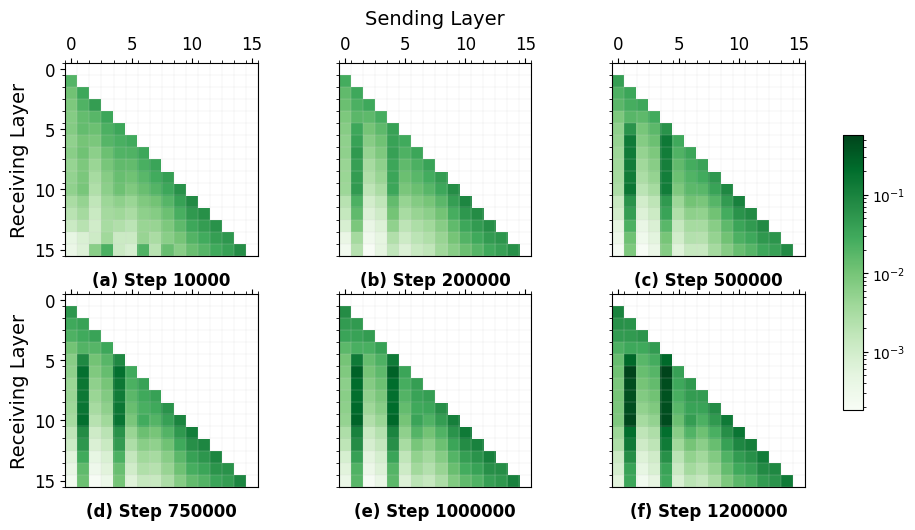

In [7]:
def training_dynamics3(raw_vars):
    vars = []
    labels = ["(a) Step 10000", "(b) Step 200000", "(c) Step 500000", "(d) Step 750000", "(e) Step 1000000", "(f) Step 1200000"]
    fig, axes = plt.subplots(2, 3, figsize=(10, 5.5))
    for ind, raw_var in enumerate(raw_vars):
        # vars.append(raw_var.detach().cpu().numpy())
        r, c = ind // 3, ind % 3
        label = labels[ind]
        var = raw_var.detach().cpu().numpy()
        ax = axes[r][c]
        im = ax.imshow(var, cmap='Greens', aspect='equal', norm=mcolors.LogNorm(vmin=moe_var_min, vmax=moe_var_max))
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')

        ax.set_xticks([0, 5, 10, 15])
        if r == 0: 
            ax.set_xticklabels(['0', '5', '10', '15'], fontsize=12)
        else:
            ax.set_xticklabels([])

        if c == 0:
            ax.set_yticks([0, 5, 10, 15])
            ax.set_yticklabels(['0', '5', '10', '15'], fontsize=12)
            ax.set_ylabel('Receiving Layer', fontsize=14, fontweight='medium')
        else:
            ax.set_yticks([])
        
        if r == 0 and c == 1:
            ax.set_xlabel('Sending Layer', fontsize=14, fontweight='medium', labelpad=8)
        
        ax.text(0.5, -0.08, label, transform=ax.transAxes, fontsize=12, ha='center', va='top', fontweight='bold')

        # if row_label:
        #     ax.text(-0.35, 0.5, row_label, transform=ax.transAxes,
        #             fontsize=14, ha='center', va='center',
        #             rotation=90, weight='bold')
            
        ax.set_xticks(np.arange(-0.5, 16, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 16, 1), minor=True)
        ax.grid(which='minor', color='lightgray', linestyle='-', linewidth=0.3, alpha=0.5)
    cax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [x, y, width, height]
    fig.colorbar(im, cax=cax)
    plt.show()
    # ax = axes[0]
training_dynamics3(moe_vars)

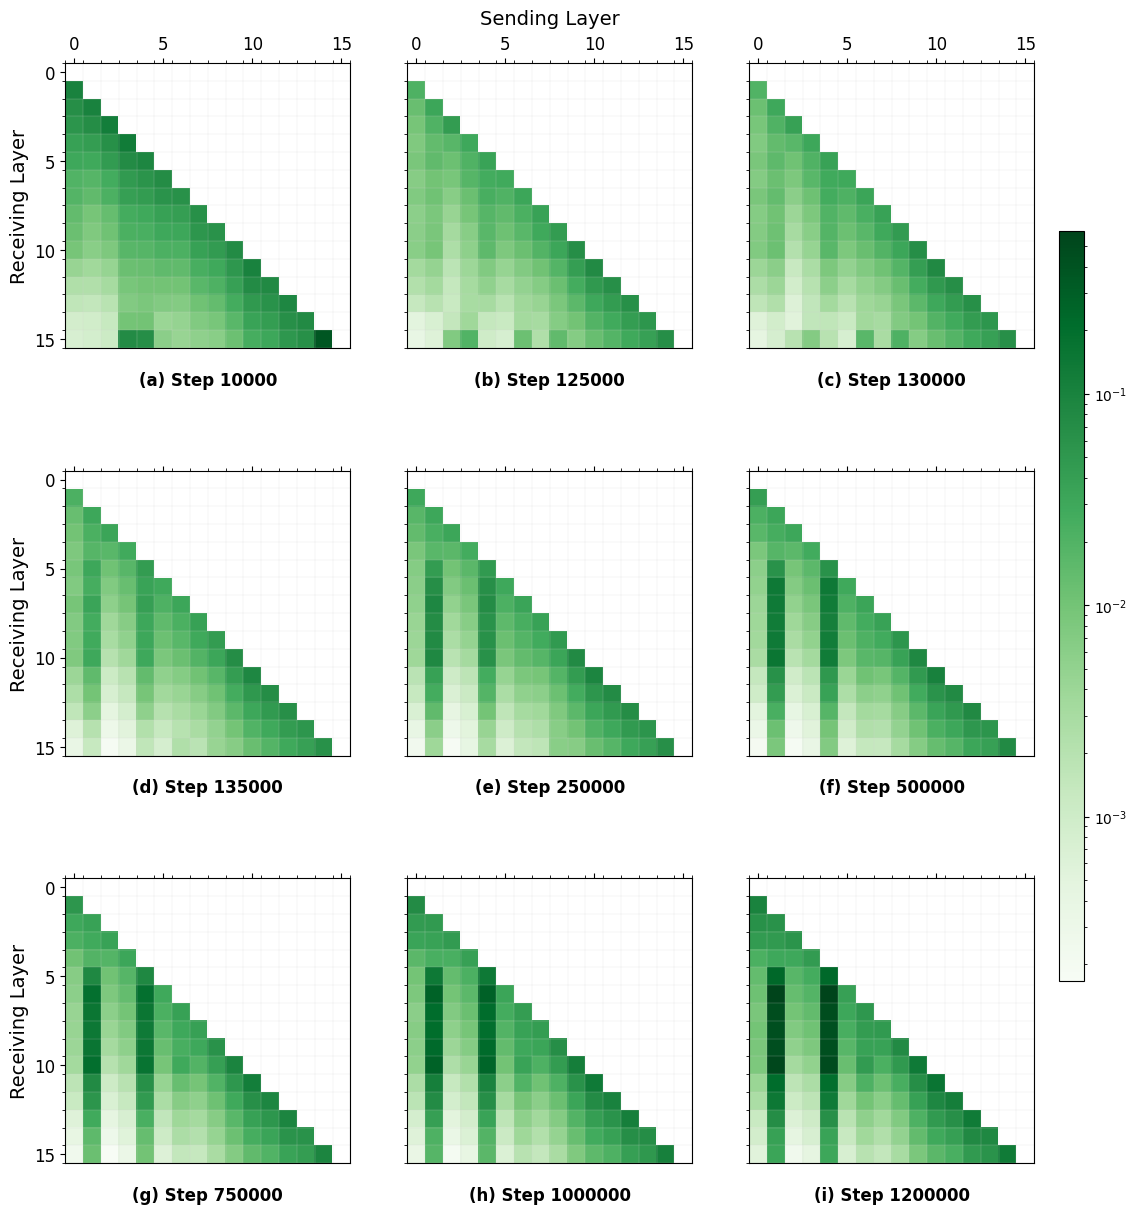

In [10]:
def training_dynamics4(raw_vars):
    vars = []
    labels = ["(a) Step 10000", "(b) Step 125000", "(c) Step 130000", "(d) Step 135000", "(e) Step 250000", "(f) Step 500000", "(g) Step 750000", "(h) Step 1000000", "(i) Step 1200000"]
    fig, axes = plt.subplots(3, 3, figsize=(12.5, 15))
    for ind, raw_var in enumerate(raw_vars):
        # vars.append(raw_var.detach().cpu().numpy())
        r, c = ind // 3, ind % 3
        label = labels[ind]
        var = raw_var.detach().cpu().numpy()
        ax = axes[r][c]
        im = ax.imshow(var, cmap='Greens', aspect='equal', norm=mcolors.LogNorm(vmin=moe_var_min, vmax=moe_var_max))
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')

        ax.set_xticks([0, 5, 10, 15])
        if r == 0: 
            ax.set_xticklabels(['0', '5', '10', '15'], fontsize=12)
        else:
            ax.set_xticklabels([])

        if c == 0:
            ax.set_yticks([0, 5, 10, 15])
            ax.set_yticklabels(['0', '5', '10', '15'], fontsize=12)
            ax.set_ylabel('Receiving Layer', fontsize=14, fontweight='medium')
        else:
            ax.set_yticks([])
        
        if r == 0 and c == 1:
            ax.set_xlabel('Sending Layer', fontsize=14, fontweight='medium', labelpad=8)
        
        ax.text(0.5, -0.08, label, transform=ax.transAxes, fontsize=12, ha='center', va='top', fontweight='bold')

        # if row_label:
        #     ax.text(-0.35, 0.5, row_label, transform=ax.transAxes,
        #             fontsize=14, ha='center', va='center',
        #             rotation=90, weight='bold')
            
        ax.set_xticks(np.arange(-0.5, 16, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 16, 1), minor=True)
        ax.grid(which='minor', color='lightgray', linestyle='-', linewidth=0.3, alpha=0.5)
    cax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [x, y, width, height]
    fig.colorbar(im, cax=cax)
    plt.show()
    # ax = axes[0]
training_dynamics4(moe_vars)

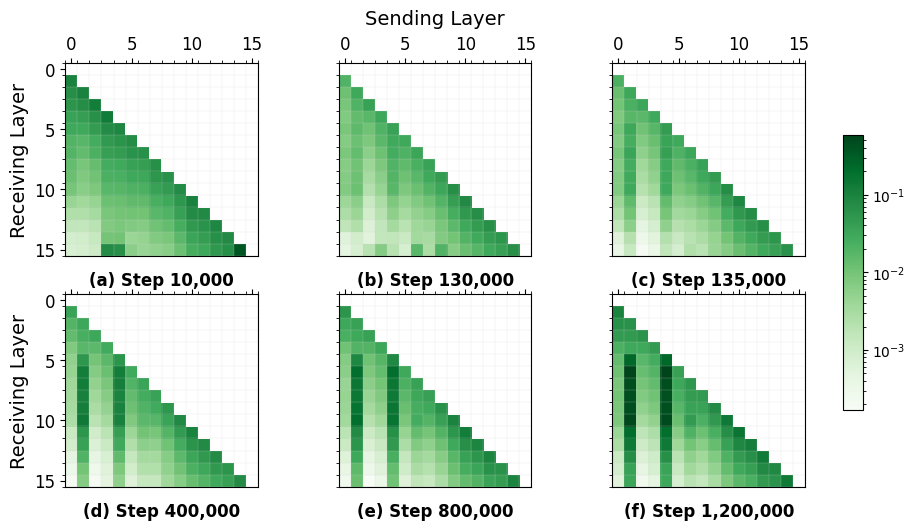

In [6]:
def training_dynamics5(raw_vars):
    vars = []
    labels = ["(a) Step 10,000", "(b) Step 130,000", "(c) Step 135,000", "(d) Step 400,000", "(e) Step 800,000", "(f) Step 1,200,000"]
    fig, axes = plt.subplots(2, 3, figsize=(10, 5.5))
    for ind, raw_var in enumerate(raw_vars):
        # vars.append(raw_var.detach().cpu().numpy())
        r, c = ind // 3, ind % 3
        label = labels[ind]
        var = raw_var.detach().cpu().numpy()
        ax = axes[r][c]
        im = ax.imshow(var, cmap='Greens', aspect='equal', norm=mcolors.LogNorm(vmin=moe_var_min, vmax=moe_var_max))
        ax.xaxis.tick_top()
        ax.xaxis.set_label_position('top')

        ax.set_xticks([0, 5, 10, 15])
        if r == 0: 
            ax.set_xticklabels(['0', '5', '10', '15'], fontsize=12)
        else:
            ax.set_xticklabels([])

        if c == 0:
            ax.set_yticks([0, 5, 10, 15])
            ax.set_yticklabels(['0', '5', '10', '15'], fontsize=12)
            ax.set_ylabel('Receiving Layer', fontsize=14, fontweight='medium')
        else:
            ax.set_yticks([])
        
        if r == 0 and c == 1:
            ax.set_xlabel('Sending Layer', fontsize=14, fontweight='medium', labelpad=8)
        
        ax.text(0.5, -0.08, label, transform=ax.transAxes, fontsize=12, ha='center', va='top', fontweight='bold')

        # if row_label:
        #     ax.text(-0.35, 0.5, row_label, transform=ax.transAxes,
        #             fontsize=14, ha='center', va='center',
        #             rotation=90, weight='bold')
            
        ax.set_xticks(np.arange(-0.5, 16, 1), minor=True)
        ax.set_yticks(np.arange(-0.5, 16, 1), minor=True)
        ax.grid(which='minor', color='lightgray', linestyle='-', linewidth=0.3, alpha=0.5)
    cax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [x, y, width, height]
    fig.colorbar(im, cax=cax)
    plt.show()
    # ax = axes[0]
training_dynamics5(moe_vars)